In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files

# Set visual theme
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

In [4]:
from google.colab import files
import pandas as pd

# 1. Select and upload file
uploaded = files.upload()

# 2. Extract uploaded filename automatically
file_name = list(uploaded.keys())[0]

# 3. Read dataset using 'latin1' encoding to handle special characters
df = pd.read_csv(file_name, encoding='latin1')

# 4. Display file name and column attributes
print(f"Uploaded File: {file_name}")
print("\nFile Attributes (Columns):")
print(df.columns.tolist())

Saving netflix_titles.csv to netflix_titles (2).csv
Uploaded File: netflix_titles (2).csv

File Attributes (Columns):
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25']


/tmp/ipykernel_1216/2584943296.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='type', palette=['#E50914', '#221F1F'])


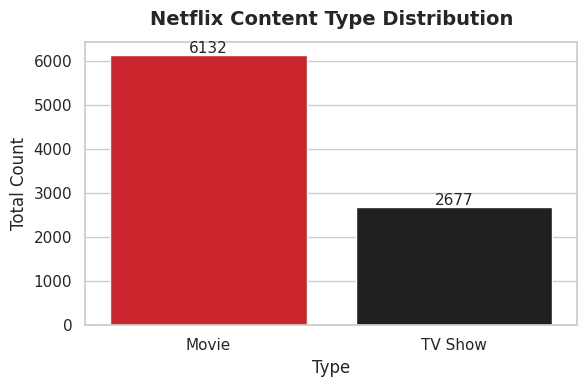

In [5]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='type', palette=['#E50914', '#221F1F'])
plt.title('Netflix Content Type Distribution', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Type')
plt.ylabel('Total Count')

# Add exact count numbers on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1216/2065036349.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')


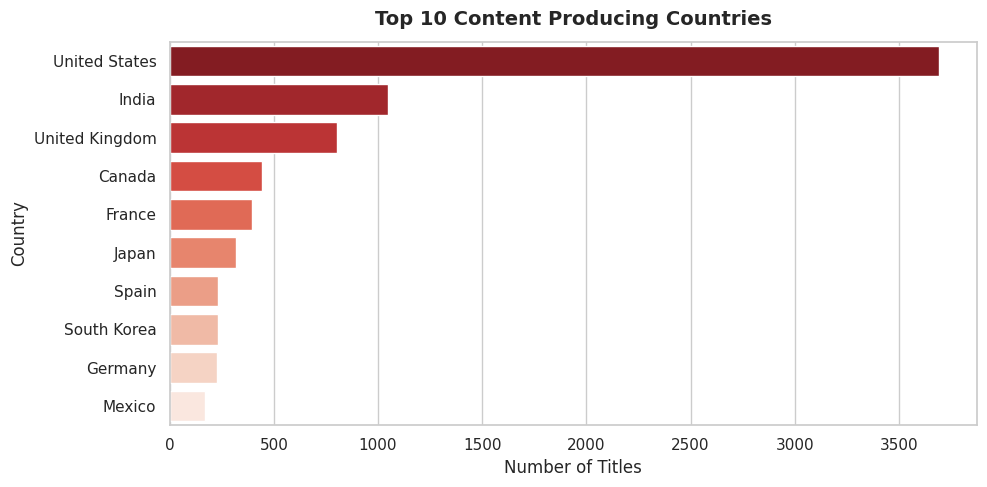

In [6]:
plt.figure(figsize=(10, 5))
# Split comma-separated country names to count individually
top_countries = df['country'].dropna().str.split(', ').explode().value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r')
plt.title('Top 10 Content Producing Countries', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1216/525045572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=rating_order, palette='viridis')


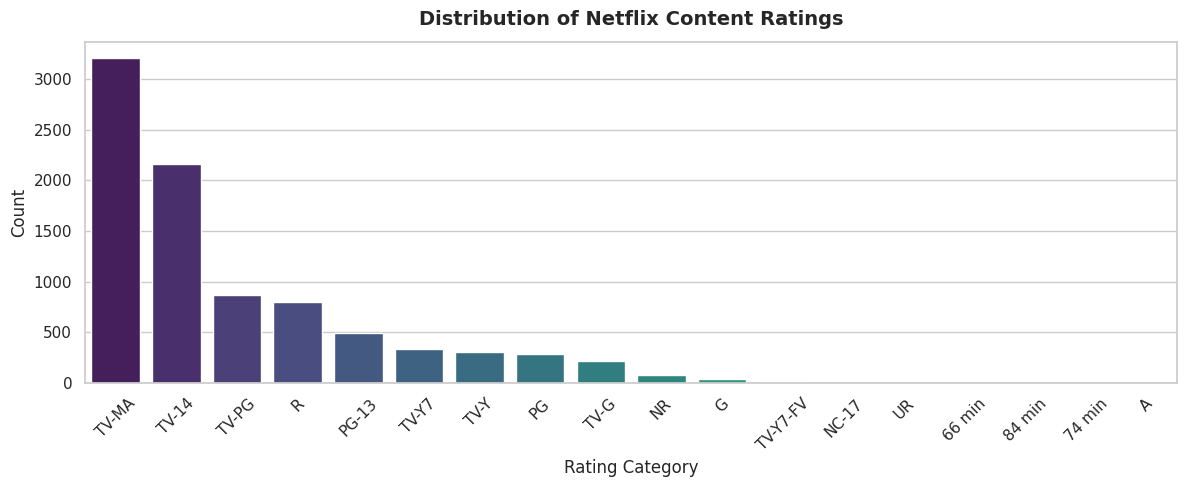

In [7]:
plt.figure(figsize=(12, 5))
rating_order = df['rating'].value_counts().index

sns.countplot(data=df, x='rating', order=rating_order, palette='viridis')
plt.title('Distribution of Netflix Content Ratings', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Rating Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

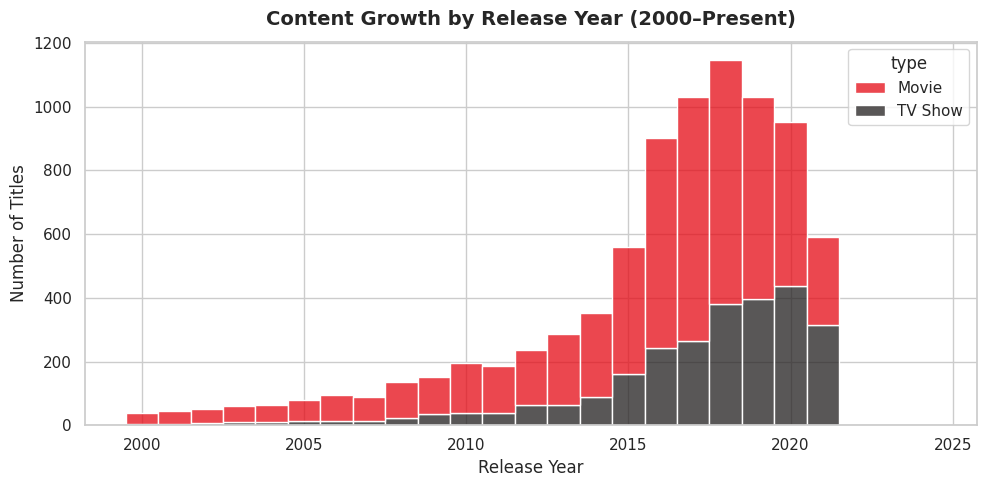

In [8]:
plt.figure(figsize=(10, 5))
df_recent = df[df['release_year'] >= 2000]

sns.histplot(data=df_recent, x='release_year', hue='type', multiple='stack',
             discrete=True, palette=['#E50914', '#221F1F'])
plt.title('Content Growth by Release Year (2000–Present)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

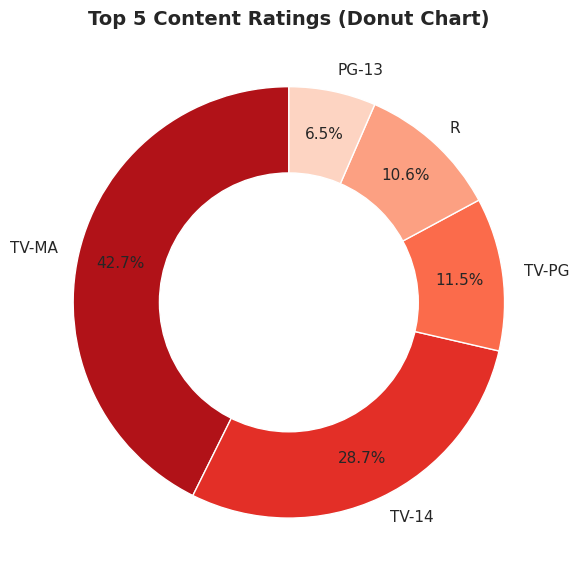

In [12]:
plt.figure(figsize=(6, 6))
top_ratings = df['rating'].value_counts().head(5)

# Draw base pie chart
plt.pie(
    top_ratings,
    labels=top_ratings.index,
    autopct='%1.1f%%',
    pctdistance=0.80,
    colors=sns.color_palette('Reds_r', 5),
    startangle=90
)

# Add a white circle in the middle to turn it into a donut
center_circle = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

plt.title('Top 5 Content Ratings (Donut Chart)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

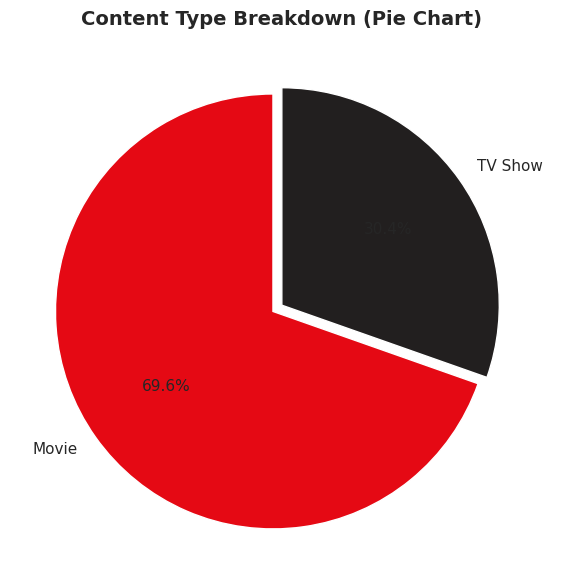

In [13]:
plt.figure(figsize=(6, 6))
type_counts = df['type'].value_counts()

# Create pie chart
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=['#E50914', '#221F1F'],
    startangle=90,
    explode=(0.05, 0)
)

plt.title('Content Type Breakdown (Pie Chart)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1216/1650097929.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1216/1650097929.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_1216/1650097929.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




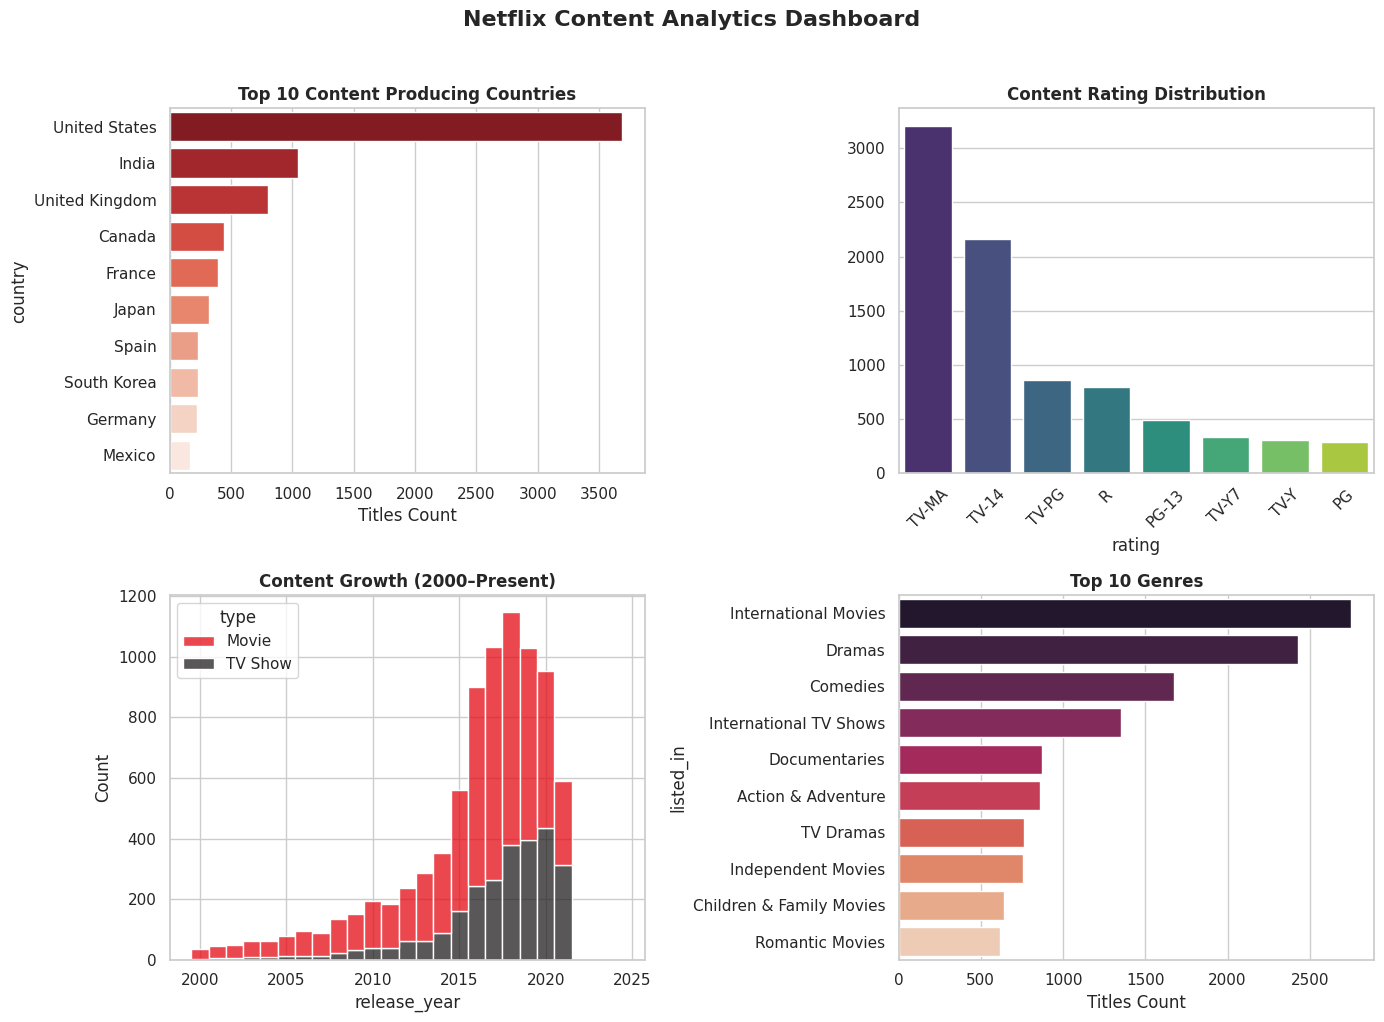

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Top 10 Countries
top_countries = df['country'].dropna().str.split(', ').explode().value_counts().head(10)
sns.barplot(ax=axes[0, 0], x=top_countries.values, y=top_countries.index, palette='Reds_r')
axes[0, 0].set_title('Top 10 Content Producing Countries', fontweight='bold')
axes[0, 0].set_xlabel('Titles Count')

# 2. Rating Breakdown
top_ratings = df['rating'].value_counts().head(8)
sns.barplot(ax=axes[0, 1], x=top_ratings.index, y=top_ratings.values, palette='viridis')
axes[0, 1].set_title('Content Rating Distribution', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Content Growth Trend
df_recent = df[df['release_year'] >= 2000]
sns.histplot(ax=axes[1, 0], data=df_recent, x='release_year', hue='type', multiple='stack', discrete=True, palette=['#E50914', '#221F1F'])
axes[1, 0].set_title('Content Growth (2000–Present)', fontweight='bold')

# 4. Top 10 Genres
top_genres = df['listed_in'].dropna().str.split(', ').explode().value_counts().head(10)
sns.barplot(ax=axes[1, 1], x=top_genres.values, y=top_genres.index, palette='rocket')
axes[1, 1].set_title('Top 10 Genres', fontweight='bold')
axes[1, 1].set_xlabel('Titles Count')

plt.suptitle('Netflix Content Analytics Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<>:6: SyntaxWarning:

invalid escape sequence '\d'

<>:6: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipykernel_1216/2565867342.py:6: SyntaxWarning:

invalid escape sequence '\d'



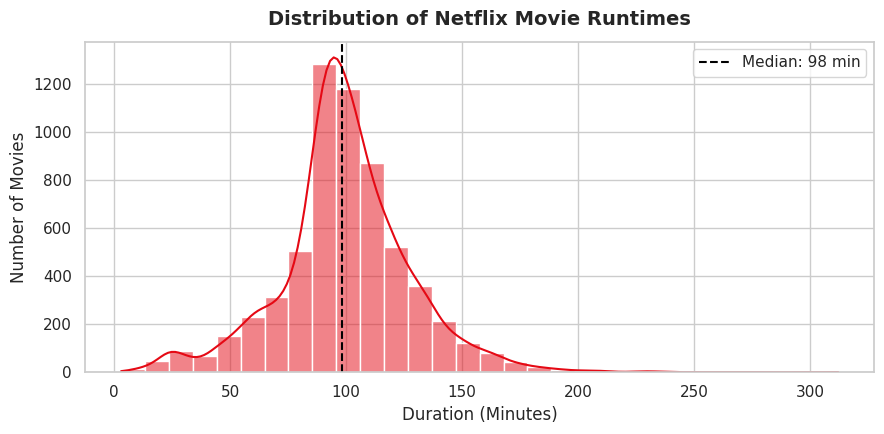

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Clean duration column for Movies
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_min'] = movies_df['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(9, 4.5))
sns.histplot(movies_df['duration_min'], kde=True, color='#E50914', bins=30)
plt.title('Distribution of Netflix Movie Runtimes', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')
plt.axvline(movies_df['duration_min'].median(), color='black', linestyle='--', label=f"Median: {movies_df['duration_min'].median():.0f} min")
plt.legend()
plt.tight_layout()
plt.show()

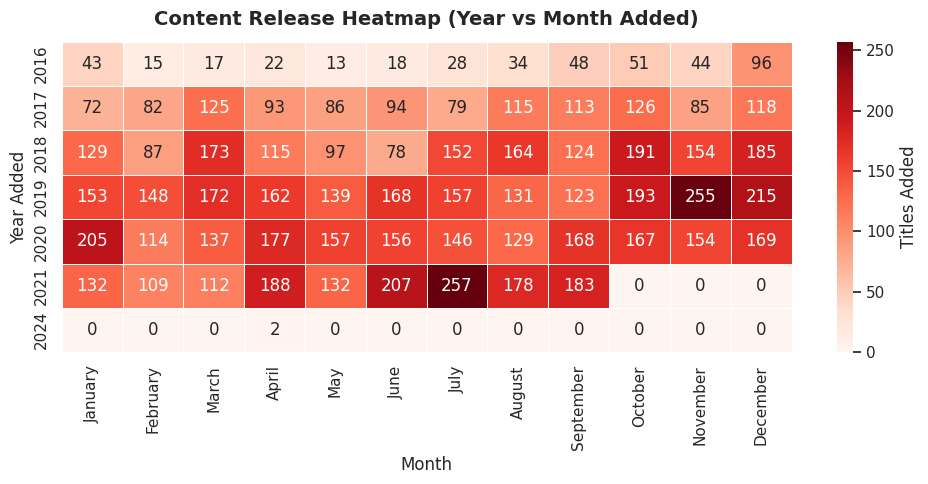

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Parse date strings
df_date = df.dropna(subset=['date_added']).copy()
df_date['date_added'] = pd.to_datetime(df_date['date_added'].str.strip())
df_date['year_added'] = df_date['date_added'].dt.year.astype(int)
df_date['month_added'] = df_date['date_added'].dt.month_name()

# Pivot data
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
pivot = df_date[df_date['year_added'] >= 2016].groupby(['year_added', 'month_added']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=months_order)

# Render Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, cmap='Reds', annot=True, fmt='d', linewidths=0.5, cbar_kws={'label': 'Titles Added'})
plt.title('Content Release Heatmap (Year vs Month Added)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Month')
plt.ylabel('Year Added')
plt.tight_layout()
plt.show()

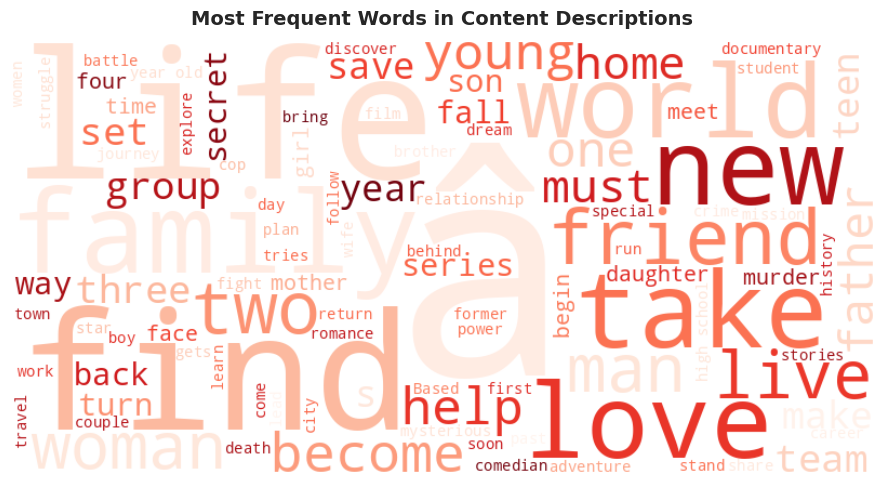

In [23]:
!pip install wordcloud

import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

text = " ".join(df['description'].dropna())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds',
    stopwords=set(STOPWORDS),
    max_words=100
).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Content Descriptions', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

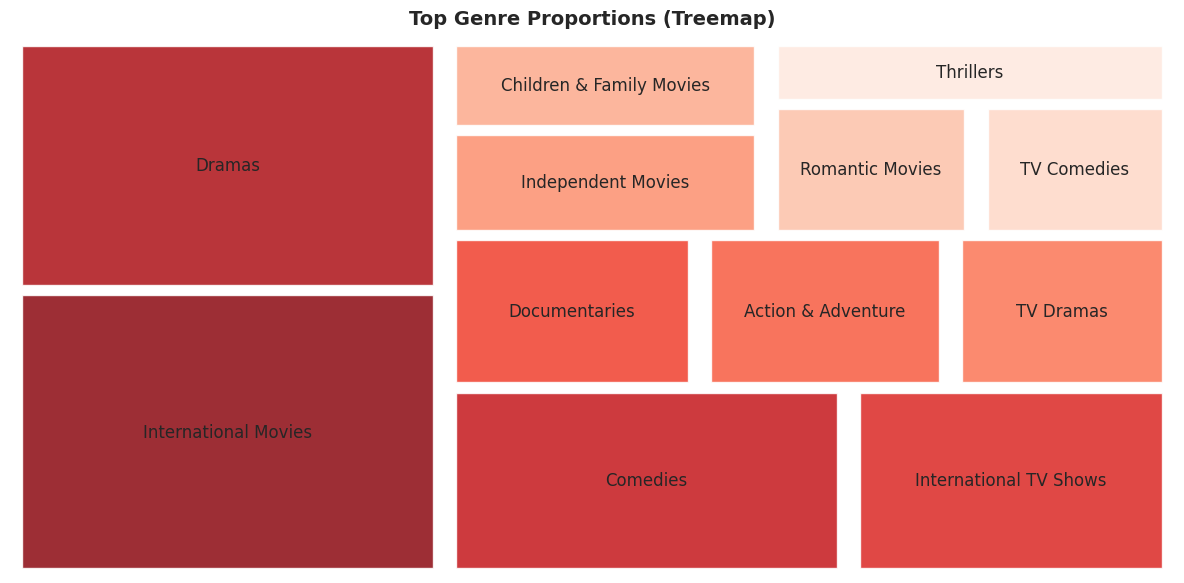

In [24]:
!pip install squarify

import squarify
import matplotlib.pyplot as plt
import seaborn as sns

top_genres = df['listed_in'].dropna().str.split(', ').explode().value_counts().head(12)

plt.figure(figsize=(12, 6))
colors = sns.color_palette("Reds_r", len(top_genres))
squarify.plot(sizes=top_genres.values, label=top_genres.index, alpha=0.85, color=colors, pad=True)
plt.title('Top Genre Proportions (Treemap)', fontsize=14, fontweight='bold', pad=12)
plt.axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1216/3355254151.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




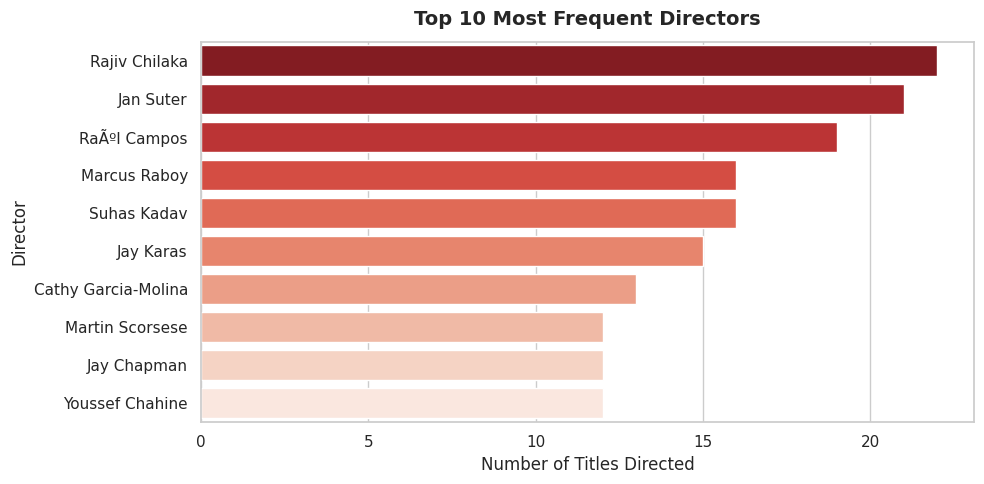

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Clean and split comma-separated directors
directors_series = df['director'].dropna().str.split(', ').explode().str.strip()
top_directors = directors_series[directors_series != ''].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='Reds_r')
plt.title('Top 10 Most Frequent Directors', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Number of Titles Directed')
plt.ylabel('Director')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1216/2334890332.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




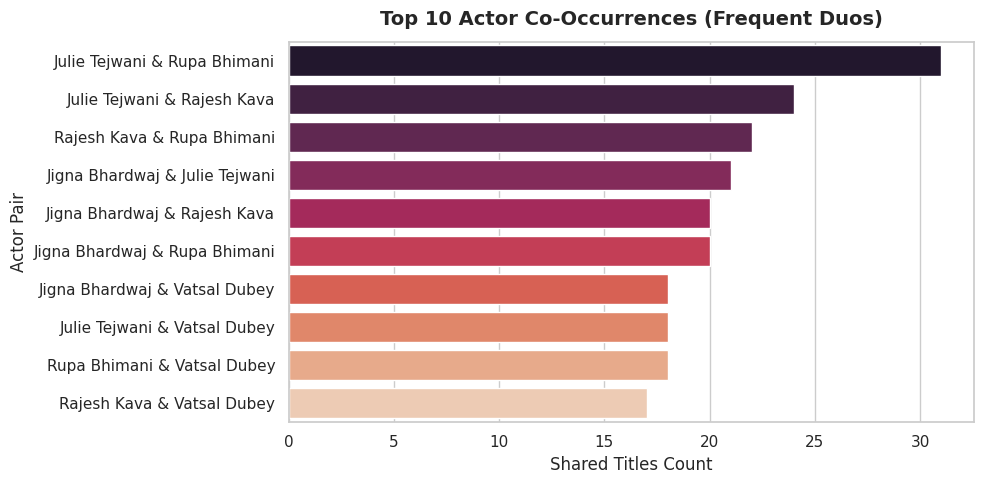

In [26]:
from itertools import combinations
from collections import Counter

pair_counter = Counter()

# Extract all pairs per movie/show
for cast_list in df['cast'].dropna():
    actors = [actor.strip() for actor in cast_list.split(',') if actor.strip()]
    if len(actors) > 1:
        # Sort names alphabetically so (A, B) matches (B, A)
        for pair in combinations(sorted(actors), 2):
            pair_counter[pair] += 1

# Convert pairs into a plot-ready DataFrame
pairs_df = pd.DataFrame(pair_counter.most_common(10), columns=['Pair', 'Count'])
pairs_df['Actor Duo'] = pairs_df['Pair'].apply(lambda x: f"{x[0]} & {x[1]}")

plt.figure(figsize=(10, 5))
sns.barplot(data=pairs_df, x='Count', y='Actor Duo', palette='rocket')
plt.title('Top 10 Actor Co-Occurrences (Frequent Duos)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Shared Titles Count')
plt.ylabel('Actor Pair')
plt.tight_layout()
plt.show()